In [256]:
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd
import random
import math
import time
random.seed(0)

In [257]:
data = pd.read_csv('/kaggle/input/are-sd-2025-classification-diagnostique-d-arbres/train.csv', index_col = "ID_ARBRE")
prev_data = pd.read_csv('/kaggle/input/are-sd-2025-classification-diagnostique-d-arbres/prev.csv', index_col = "ID_ARBRE")
data.head()

,quartier,site,genre_arbre,situation,type_sol,surf_permeable,classe_age,hauteur,classe_hauteur,diametre,...,fissure_houppier,ecorce_incluse_houppier,bois_mort_houppier,plaie_houppier,observation_houppier,esperance_maintien,contrainte,classification_diagnostic,Long,Lat
ID_ARBRE,,,,,,,,,,,,,,,,,,,,,
0,Quartier 3 - Lycée International,RN13,Tilia,Alignement,MA,4.0,A,500,H1,31.830989,...,HPF,Non,HPBM,HPLS,0,1.0,Non,C1,2.064,48.900
1,Quartier 2 - Alsace - Pereire,Avenue du Maréchal Foch,Tilia,Alignement,MA,4.0,A,800,H2,76.394373,...,HFO,Non,HPBM,HPLNC,Fissure ouverte axe2 2M Sud Est,2.0,Oui,C4,2.085,48.903
2,Quartier 2 - Alsace - Pereire,RN13,Tilia,Alignement,GR,4.0,A,500,H1,38.197186,...,HPF,Non,HPBM,HPLS,0,1.0,Non,C1,2.070,48.899
3,Quartier 1 - Cœur de Ville et Quatier forestier,Avenue Gambetta,Tilia,Alignement,Gr,1.0,A,600,H2,66.845076,...,HPF,Non,HPBM,HPLS,Branches cassées,1.0,Non,C2,2.099,48.897
4,Quartier 1 - Cœur de Ville et Quatier forestier,Rue Thiers,Cercis,Isolé,MA,20.0,JA,400,H1,25.464791,...,HPF,Non,HPBM,HPPL,0,1.0,Non,C2,2.101,48.898


# Analyse Descriptive

In [258]:
len(data)

544

In [259]:
len(prev_data)

137

In [260]:
prev_data.head()

,quartier,site,genre_arbre,situation,type_sol,surf_permeable,classe_age,hauteur,classe_hauteur,diametre,...,fissure_houppier,ecorce_incluse_houppier,bois_mort_houppier,plaie_houppier,observation_houppier,esperance_maintien,contrainte,Long,Lat,Usage
ID_ARBRE,,,,,,,,,,,,,,,,,,,,,
559,Quartier 2 - Alsace - Pereire,Avenue du Maréchal Foch,Tilia,Alignement,MA,4.0,A,800,H2,44.563384,...,HPF,Non,HPBM,HPLNC,Branches cassées,2.0,Non,2.084,48.904,Private
560,Quartier 4 - Rotondes - St Léger,Avenue Saint-Fiacre,Carpinus,Alignement,Gr,1.0,JA,800,H2,38.197186,...,HPF,Non,HPBM,HPLS,0,1.0,Non,2.072,48.895,Private
561,Quartier 2 - Alsace - Pereire,Avenue du Maréchal Foch,Tilia,Alignement,MA,4.0,A,800,H2,63.661977,...,HPF,Non,HPBM,HPLS,0,2.0,Non,2.083,48.904,Private
562,Quartier 4 - Rotondes - St Léger,Rue Saint-Leger,Fraxinus,Alignement,Gr,1.0,J,500,H1,22.281692,...,HPF,Non,HPBM,HPLS,0,1.0,Non,2.066,48.895,Private
563,Quartier 4 - Rotondes - St Léger,Rue Saint-Leger,Prunus,Alignement,S,1.0,A,500,H1,70.028175,...,HPF,Non,HPBM,HPLNC,Phellin du fruitier,2.0,Non,2.072,48.898,Private


In [261]:
np.unique(data['classe_hauteur'])

array(['H1', 'H2', 'H3', 'H4', 'H5'], dtype=object)

In [262]:
data.columns

Index(['quartier', 'site', 'genre_arbre', 'situation', 'type_sol',
       'surf_permeable', 'classe_age', 'hauteur', 'classe_hauteur', 'diametre',
       'circonference (en cm)', 'classe_circonference', 'port_arbre',
       'vigueur_pousse', 'champignon_collet', 'insecte_collet', 'plaie_collet',
       'observation_collet', 'champignon_tronc', 'insecte_tronc',
       'fissure_tronc', 'rejet_tronc', 'tuteurage_arbre', 'canisse_arbre',
       'plaie_tronc', 'observation_tronc', 'champignon_houppier',
       'insecte_houppier', 'fissure_houppier', 'ecorce_incluse_houppier',
       'bois_mort_houppier', 'plaie_houppier', 'observation_houppier',
       'esperance_maintien', 'contrainte', 'classification_diagnostic', 'Long',
       'Lat'],
      dtype='object')

In [263]:
prev_data.columns

Index(['quartier', 'site', 'genre_arbre', 'situation', 'type_sol',
       'surf_permeable', 'classe_age', 'hauteur', 'classe_hauteur', 'diametre',
       'circonference (en cm)', 'classe_circonference', 'port_arbre',
       'vigueur_pousse', 'champignon_collet', 'insecte_collet', 'plaie_collet',
       'observation_collet', 'champignon_tronc', 'insecte_tronc',
       'fissure_tronc', 'rejet_tronc', 'tuteurage_arbre', 'canisse_arbre',
       'plaie_tronc', 'observation_tronc', 'champignon_houppier',
       'insecte_houppier', 'fissure_houppier', 'ecorce_incluse_houppier',
       'bois_mort_houppier', 'plaie_houppier', 'observation_houppier',
       'esperance_maintien', 'contrainte', 'Long', 'Lat', 'Usage'],
      dtype='object')

#### prev_data manque de la colonne "classification_diagnostic" que l'on doit prévoir mais il possède la colonne "Usage" indiquant si l'arbre appartient au leaderboard privé ou public

(array([185.,   0.,   7.,   0.,   0., 315.,   0.,  31.,   0.,   6.]),
 array([0. , 0.4, 0.8, 1.2, 1.6, 2. , 2.4, 2.8, 3.2, 3.6, 4. ]),
 <BarContainer object of 10 artists>)

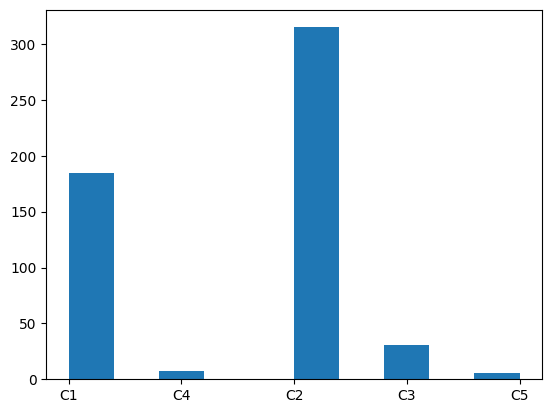

In [264]:
plt.hist(data['classification_diagnostic'])

In [265]:
data['classification_diagnostic'].value_counts(normalize=True)

classification_diagnostic
C2    0.579044
C1    0.340074
C3    0.056985
C4    0.012868
C5    0.011029
Name: proportion, dtype: float64

### On observe qu'il y a une grande majorité de C2 (57%), de C1 (34%) et que les 3 autres classes sont sous-représentées

(array([280.,   0.,   0., 140.,   0.,   0., 122.,   0.,   0.,   2.]),
 array([0. , 0.3, 0.6, 0.9, 1.2, 1.5, 1.8, 2.1, 2.4, 2.7, 3. ]),
 <BarContainer object of 10 artists>)

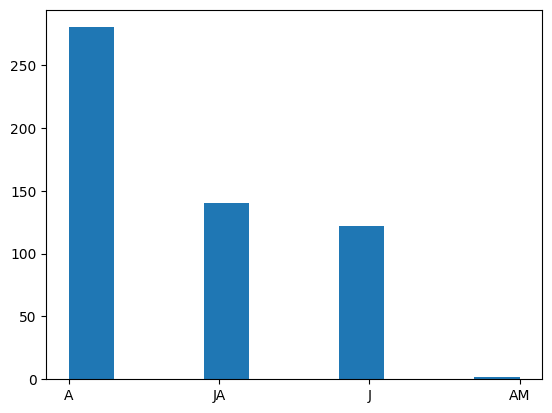

In [266]:
plt.hist(data['classe_age'])

In [267]:
classes = np.unique(data['classification_diagnostic'])
eff = [[len(data[(data['classe_age'] == 'J') & (data['classification_diagnostic'] == c)]) for c in classes],
       [len(data[(data['classe_age'] == 'JA') & (data['classification_diagnostic'] == c)]) for c in classes],
       [len(data[(data['classe_age'] == 'A') & (data['classification_diagnostic'] == c)]) for c in classes],
       [len(data[(data['classe_age'] == 'AM') & (data['classification_diagnostic'] == c)]) for c in classes]]

In [268]:
eff 
#1 = Jeunes (âge < 10 ans )
#2 = Jeunes Adultes (de 10 à 20 ans)
#3 = Adultes (de 20 à 40 ans)
#4 = Adultes mûrs (de 50 à 70 ans)

[[77, 42, 2, 1, 0], [50, 72, 16, 1, 1], [58, 199, 13, 5, 5], [0, 2, 0, 0, 0]]

In [269]:
eff_pourcent = [[len(data[(data['classe_age'] == 'J') & (data['classification_diagnostic'] == c)])*100/len(data) for c in classes],
       [len(data[(data['classe_age'] == 'JA') & (data['classification_diagnostic'] == c)])*100/len(data) for c in classes],
       [len(data[(data['classe_age'] == 'A') & (data['classification_diagnostic'] == c)])*100/len(data) for c in classes],
       [len(data[(data['classe_age'] == 'AM') & (data['classification_diagnostic'] == c)])*100/len(data) for c in classes]]

In [270]:
eff_pourcent

[[14.154411764705882,
  7.720588235294118,
  0.36764705882352944,
  0.18382352941176472,
  0.0],
 [9.191176470588236,
  13.235294117647058,
  2.9411764705882355,
  0.18382352941176472,
  0.18382352941176472],
 [10.661764705882353,
  36.580882352941174,
  2.389705882352941,
  0.9191176470588235,
  0.9191176470588235],
 [0.0, 0.36764705882352944, 0.0, 0.0, 0.0]]

In [271]:
#100% des arbres > 50 ans sont C2
#72% des arbres > 20 ans sont C2
#Plus les arbres sont vieux, plus ils ont de chance d'appartenir à C2 

# Classificateur de Bayes

In [272]:
def jointe(data, v1, v2):
    """
    Prend en paramètre un dataset et deux nom de colonnes puis renvoie la loi jointe 
    """
    x1 = data[v1]
    x2 = data[v2]
    res = [np.zeros(len(np.unique(data[v1]))) for i in range(len(np.unique(data[v2])))]
    for i in range(len(np.unique(data[v1]))):
        for j in range(len(np.unique(data[v2]))):
            res[j][i] = (len(data[(data[v2] == np.unique(data[v2])[j]) & (data[v1] == np.unique(data[v1])[i])])) / len(data)
    return res

In [273]:
resultat = jointe(data, 'classification_diagnostic', 'classe_age')
resultat

[array([0.10661765, 0.36580882, 0.02389706, 0.00919118, 0.00919118]),
 array([0.        , 0.00367647, 0.        , 0.        , 0.        ]),
 array([0.14154412, 0.07720588, 0.00367647, 0.00183824, 0.        ]),
 array([0.09191176, 0.13235294, 0.02941176, 0.00183824, 0.00183824])]

In [274]:
def Bayes(prev, loi_jointe, X):
    """
    Prend en paramètre une loi_jointe, un dataset de prévision et le nom d'une colonne X
    puis applique le classificateur de Bayes pour renvoyer la colonne de prévision Y
    """
    y = prev[X].copy()
    uniqueX = list(np.unique(prev[X]))
    uniqueY = list(np.unique(data['classification_diagnostic']))
    for i in range(len(prev[X])):
        x = y.iloc[i]
        arg = uniqueX.index(x)
        y.iloc[i] = uniqueY[np.argmax(loi_jointe[arg])]
    return y

## Première prévision

In [275]:
y_prev = Bayes(prev_data, jointe(data, 'classification_diagnostic', 'classe_age'), 'classe_age')
y_prev = pd.DataFrame(y_prev)
y_prev = y_prev.rename(columns={"classe_age": "classification_diagnostic"}) #Convertion de la colonne Y en benchmark pour soumettre
y_prev

,classification_diagnostic
ID_ARBRE,
559,C2
560,C1
561,C2
562,C2
563,C2
...,...
694,C2
695,C1
696,C1


In [276]:
y_prev.to_csv('BayesAge.csv', index = True, index_label = 'ID_ARBRE') #Extraction du benchmark

### Résultat: 63.2%

## Deuxième prévision

In [277]:
y_prev = Bayes(prev_data, jointe(data, 'classification_diagnostic', 'site'), 'site')
y_prev = pd.DataFrame(y_prev)
y_prev = y_prev.rename(columns={"site": "classification_diagnostic"}) #Convertion de la colonne Y en benchmark pour soumettre
y_prev

,classification_diagnostic
ID_ARBRE,
559,C2
560,C2
561,C2
562,C1
563,C1
...,...
694,C2
695,C2
696,C2


In [278]:
y_prev.to_csv('BayesSite.csv', index = True, index_label = 'ID_ARBRE') #Extraction du benchmark

### Prévision: 69.4%, meilleur résultat que sur la variable précédente

In [279]:
def precision(prev, y_prev, Y):
    accuracy = 0
    prev = prev[Y].copy()
    y_prev = y_prev[Y].copy()
    for i in range(len(prev)):
        if y_prev.iloc[i] == prev.iloc[i]:
            accuracy += 1
    return (100*accuracy)/len(prev)

In [280]:
y_prev = Bayes(data, jointe(data, 'classification_diagnostic', 'site'), 'site')
y_prev = pd.DataFrame(y_prev)
y_prev = y_prev.rename(columns={"site": "classification_diagnostic"})
precision(data, y_prev, 'classification_diagnostic')

77.20588235294117

# Classificateur de Bayes naïf

In [281]:
def NaiveBayes(prev, loi_jointes, X):
    """
    Prend en paramètre une liste de loi_jointe, un dataset de prévision et le nom d'une colonne X
    puis applique le classificateur de Bayes pour renvoyer la colonne de prévision Y
    """
    y = prev[X].copy()  
    uniqueX = list(np.unique(prev[X]))  
    uniqueY = list(np.unique(prev['classification_diagnostic']))  

    num_observations = len(prev)
    loi_jointe_combined = []
    for i in range(num_observations):
        prob = 1  
        for loi in lois_jointes:
            prob *= loi[i]
        loi_jointe_combined.append(prob)

    for i in range(len(prev[X])):
        x = y.iloc[i]  
        arg = uniqueX.index(x)  
        y.iloc[i] = uniqueY[np.argmax([loi_jointe_combined[arg]])]
    
    return y

In [282]:
#Création des loi_jointes:

loi_site = jointe(data, 'classification_diagnostic', 'site') 
loi_classe_age = jointe(data, 'classification_diagnostic', 'classe_age')
loi_genre_arbre = jointe(data, 'classification_diagnostic', 'genre_arbre')  
loi_hauteur = jointe(data, 'classification_diagnostic', 'hauteur') 
loi_circonference = jointe(data, 'classification_diagnostic', 'circonference (en cm)')
lois_jointes = [loi_site, loi_classe_age, loi_genre_arbre, loi_hauteur, loi_circonference]

#Prévisions:

#y_prev = NaiveBayes(data, lois_jointes, 'classification_diagnostic')
#y_prev = pd.DataFrame(y_prev)
#y_prev = y_prev.rename(columns={"site": "classification_diagnostic"})
#y_prev
#precision(data, y_prev, 'classification_diagnostic')

#### Nous n'avons malheureusement pas réussi a implémenter le classificateur de Bayes à plusieurs variables (problème au niveau de la multiplication de loi jointes)

# KNN K-plus proches voisins

In [283]:
X_train = data.drop(columns=['classification_diagnostic'])
y_train = data['classification_diagnostic']
X_test = prev_data

In [284]:
def compute_distance(X, Y):
    return np.sum(np.square(X-Y))

In [285]:
def knn_predict(k, X_train, Y_train, prev_row, label_column = 'classification_diagnostic'):
    #pour chaque ligne train_row de data_train:
    #- calculer la distance entre prev_row et train_row
    #- range la distance dans une liste
    #trier les indices par distance décroissante
    #faire le vote majoritaire des k premiers indices de la liste triée
    distances_list = []
    for i in range(len(X_train)):
        train_row = X_train.iloc[i]
        distances_list.append(compute_distance(train_row, prev_row))
    sorted_indices = np.argsort(distances_list[:k])
    predictions = {}
    max_votes = 0
    for index in sorted_indices:
        label = y_train[index]
        if label in predictions:
            predictions[label] += 1
        else:
            predictions[label] = 1
        if predictions[label] > max_votes:
            max_votes = predictions[label]
        candidates = [key for key in predictions if predictions[key] == max_votes]
    return 0

In [286]:
n = len(data)
k = 10

def knn(data, prev_data, k, n):
    pred_labels = []
    for i in range(n):
        pred_labels.append(knn_predict(k, x_train, y_train, x_test.iloc[i]))
    return pred_labels

### Ce modèle possède de trop longs calcul des distances (et n'a pas des très bons résultats) avec un k trop élevé, On calcule donc la distance via la fonction cdist du module scipy

In [287]:
from scipy.spatial.distance import cdist

In [288]:
def knn_with_cdist(X_train, y_train, X_test, k):
    # Calculer la matrice des distances (X_test vs X_train)
    dists = cdist(X_test, X_train, metric='euclidean')  # shape: (len(X_test), len(X_train))
    
    predictions = []
    
    for i in range(dists.shape[0]):
        # Obtenir les indices des k plus proches voisins
        k_indices = np.argsort(dists[i])[:k]
        
        # Récupérer les labels correspondants
        k_labels = [y_train.iloc[idx] for idx in k_indices]

        
        # Vote majoritaire
        votes = {}
        for label in k_labels:
            votes[label] = votes.get(label, 0) + 1
        
        predicted_label = max(votes, key=votes.get)
        predictions.append(predicted_label)
    
    return predictions

In [289]:
for col in X_train.columns:
    if X_train[col].dtype == 'object':
        unique_vals = X_train[col].unique()
        mapping = {val: idx for idx, val in enumerate(unique_vals)}
        X_train[col] = X_train[col].map(mapping)
        X_test[col] = X_test[col].map(mapping)

#Prévisions:

common_cols = list(X_train.columns)
X_test = X_test[common_cols]
pred = knn_with_cdist(X_train.values, y_train, X_test.values, k=1)

In [290]:
y_pred = prev_data['site'].copy()
y_pred = pd.DataFrame(y_pred)
y_pred['site'] = pred
y_pred = y_pred.rename(columns={"site": "classification_diagnostic"}) #Convertion de la colonne Y en benchmark pour soumettre
y_pred

,classification_diagnostic
ID_ARBRE,
559,C2
560,C2
561,C2
562,C1
563,C1
...,...
694,C2
695,C2
696,C2


In [291]:
y_pred.to_csv('KNN1.csv', index = True, index_label = 'ID_ARBRE') #Extraction du benchmark

## Résultats: 

#### k = 1: 75.5%

#### k = 3: 77.5%

#### k = 10: 77.5%

#### k = 24: 71.4%

#### k = 50: 71.4%

### On obtient les meilleurs résultats lorsque 1 < k < 15 et on obtient des meilleurs résultats avec KNN qu'avec Bayes

# Validation Croisée

In [292]:
def split_train_test(x, pourcentage):
    if pourcentage != 0:
        n = len(x) - len(x)//pourcentage
    else:
        n = len(x)
    return (x[0: n], x[n: -1]) 

In [293]:
def validation_croisee(x, N, k_list, variables):
    accuracy = []
    for pourcentage in range(10, 100, N):
        train_split, test_split = split_train_test(x, pourcentage)
        x_train_split, y_train_split = train_split[variables], train_split['classification_diagnostic']
        x_test_split, y_test_split = test_split[variables], test_split['classification_diagnostic']
        prevision = knn(k_list[pourcentage], x_test_split, variables, "classification_diagnostic", y_test_split, "classification_diagnostic")
        accuracy.append(precision(precision(x_test_split, prevision, 'classification_diagnostic')))
    return (k_list[np.argmax(accuracy)], np.max(accuracy))

### Nous n'avons pas eu le temps d'implémenter complètement la validation croisée

# Arbres - Gini

## **Indice de Gini** :

#### Permet de mesurer l'inégalité entre les valeurs d'un ensemble, on va chercher à minimiser cet indice

In [294]:
def gini(x):
    """Prend une liste de classes en paramètre et renvoie l'indice de Gini"""
    total = 0
    for i, xi in enumerate(x[:-1], 1):
        total += np.sum(np.abs(xi - x[i:]))
    return total / (len(x)**2 * np.mean(x))

In [295]:
def occur(liste, elt):
    """Prend une liste et un élément en paramètre et 
       renvoie le nombre d'occurence de cet élément dans la liste.
    """
    occ = 0
    for i in range(liste):
        if liste[i] == elt:
            occ += 1
    return occ

In [296]:
def classe_majoritaire(noeud):
    """Prend les classes d'un noeud en paramètre et renvoie la classe majoritaire"""
    unique = np.unique(data['classification_diagnostic'])
    classes = []
    classe = []
    for data in noeud:
        classes.append(data["classification_diagnostic"])
    for i in range(unique):
        classe.append(occur(classes, unique[i]))
    return unique[np.argmax(classe)]

## Construction d'un arbre

In [297]:
def best_split(X, y):
    n_samples, n_features = X.shape
    best_gini = 1.0
    best_feature = None
    best_threshold = None

    for feature in range(n_features):
        thresholds = np.unique(X[:, feature])
        for t in thresholds:
            left_indices = X[:, feature] <= t
            right_indices = X[:, feature] > t

            if sum(left_indices) == 0 or sum(right_indices) == 0:
                continue

            y_left, y_right = y[left_indices], y[right_indices]
            g = (len(y_left) / n_samples) * gini(y_left) + (len(y_right) / n_samples) * gini(y_right)

            if g < best_gini:
                best_gini = g
                best_feature = feature
                best_threshold = t

    return best_feature, best_threshold

In [298]:
class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, *, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value  # Classe prédite (si feuille, None sinon)

    def is_leaf(self):
        return self.value is not None

def build_tree(X, y, depth=0, max_depth=15):
    # Cas d'arrêt
    if len(set(y)) == 1 or depth == max_depth:
        # Retourne une feuille
        value = max(set(y), key=list(y).count)
        return Node(value=value)

    feature, threshold = best_split(X, y)
    if feature is None:
        value = max(set(y), key=list(y).count)
        return Node(value=value)

    left_indices = X[:, feature] <= threshold
    right_indices = X[:, feature] > threshold

    left = build_tree(X[left_indices], y[left_indices], depth+1, max_depth)
    right = build_tree(X[right_indices], y[right_indices], depth+1, max_depth)

    return Node(feature, threshold, left, right)

In [299]:
def predict_one(x, node):
    if node.is_leaf():
        return node.value
    if x[node.feature] <= node.threshold:
        return predict_one(x, node.left)
    else:
        return predict_one(x, node.right)

def predict(X, tree):
    return [predict_one(x, tree) for x in X]

In [300]:
X_train_np = X_train.to_numpy()
y_train_np = y_train.to_numpy()
X_test_np = X_test.to_numpy()

# Encoder les labels en int
label_mapping = {label: idx for idx, label in enumerate(np.unique(y_train_np))}
y_train_encoded = np.array([label_mapping[label] for label in y_train_np])

In [301]:
# Construire l'arbre avec profondeur max de 15
tree = build_tree(X_train_np, y_train_encoded, max_depth=15)

# Prévisions:

y_pred_encoded = predict(X_test_np, tree)
inv_label_mapping = {v: k for k, v in label_mapping.items()}
y_pred = [inv_label_mapping[p] for p in y_pred_encoded]
y_pred_df = pd.DataFrame(y_pred, index=X_test.index, columns=["classification_diagnostic"])

<ipython-input-294-e4f8e85bba33>:6: RuntimeWarning: invalid value encountered in scalar divide
  return total / (len(x)**2 * np.mean(x))


In [302]:
y_pred_df 

,classification_diagnostic
ID_ARBRE,
559,C2
560,C2
561,C2
562,C1
563,C3
...,...
694,C2
695,C2
696,C2


In [303]:
y_pred_df.to_csv('ArbreGini15.csv', index = True, index_label = 'ID_ARBRE') #Extraction du benchmark

## Résultats:

#### Profondeur max = 5: 65.3%

#### Profondeur max = 15: 83.6%

#### Profondeur max = 20: 77.5%

### On obtient les meilleurs résultats lorsque la profondeur = 15 et les arbres possèdent de meilleurs résultats que KNN et Bayes

# Conclusion

1. Pour chacun des algorithmes présentés, nous avont fait face à certains problèmes :
   
    * Bayes : Utiliser plusieurs variables
    * KNN: Calculer les distances sans avoir de trop long temps de calcul
    * Arbres: Très difficile a implémenter (beaucoup de recherche internet nécéssaire pour comprendre et réussir à construire un modèle fonctionnel)

---

2. Meilleurs résultats :

    * Bayes: 69.4%
    * KNN: 77.5%
    * Arbres: 83.6%

---

3. Ce qu'on a aimé:

    * Travail autonome, interaction avec un professionel, experience de prédiction
    * Travail de recherche
    * Avoir mis en pratique ce qu'on a appris pendant le premier semestre (KNN, Bayes) et apprendre d'autres modèles (Arbres, Random forest)